# Used Car Market Analysis — Exploratory Data Analysis (EDA)


## Análisis del mercado de autos usados — Análisis Exploratorio de Datos

### Libraries Import | Importación de librerías

In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### DataFrame Creation and Preliminary Review | Creación del DataFrame y revisión preliminar
The dataset contains 426,880 listings scraped from Craigslist (2021) with information about used vehicles across the United States.

El dataset contiene 426,880 anuncios extraídos de Craigslist (2021) con información sobre vehículos usados en Estados Unidos.


In [56]:
df = pd.read_csv('vehicles.csv')

In [57]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 26 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   url           426880 non-null  str    
 2   region        426880 non-null  str    
 3   region_url    426880 non-null  str    
 4   price         426880 non-null  int64  
 5   year          425675 non-null  float64
 6   manufacturer  409234 non-null  str    
 7   model         421603 non-null  str    
 8   condition     252776 non-null  str    
 9   cylinders     249202 non-null  str    
 10  fuel          423867 non-null  str    
 11  odometer      422480 non-null  float64
 12  title_status  418638 non-null  str    
 13  transmission  424324 non-null  str    
 14  VIN           265838 non-null  str    
 15  drive         296313 non-null  str    
 16  size          120519 non-null  str    
 17  type          334022 non-null  str    
 18  paint_color   2

In [58]:
print(df.sample(5))

                id                                                url  \
299765  7302253269  https://dayton.craigslist.org/ctd/d/dayton-201...   
104105  7303759447  https://okaloosa.craigslist.org/cto/d/miramar-...   
114004  7316279903  https://spacecoast.craigslist.org/ctd/d/merrit...   
128194  7316063144  https://honolulu.craigslist.org/oah/ctd/d/fort...   
122673  7315531727  https://atlanta.craigslist.org/atl/ctd/d/atlan...   

                      region                         region_url  price  \
299765  dayton / springfield      https://dayton.craigslist.org  12999   
104105     okaloosa / walton    https://okaloosa.craigslist.org  19250   
114004           space coast  https://spacecoast.craigslist.org   7991   
128194                hawaii    https://honolulu.craigslist.org  23990   
122673               atlanta     https://atlanta.craigslist.org  17990   

          year   manufacturer                  model  condition    cylinders  \
299765  2016.0           ford       

### Data Cleaning | Limpieza de datos
Removing columns and records not relevant to the analysis.

Eliminamos columnas y registros no relevantes para el análisis.

#### Price Column Analysis | Análisis de la columna 'price'

In [59]:
print(df['price'].describe())

count    4.268800e+05
mean     7.519903e+04
std      1.218228e+07
min      0.000000e+00
25%      5.900000e+03
50%      1.395000e+04
75%      2.648575e+04
max      3.736929e+09
Name: price, dtype: float64


The dataset shows extreme price variability — from $0 to $3.7B — indicating placeholder values and data entry errors. For this analysis, we will only consider vehicles priced between **$1,000 and $100,000**, which represents the realistic used car market range.

El dataset muestra una variabilidad extrema de precios — desde $0 hasta $3,700M — indicando valores placeholder y errores de captura. Para este análisis consideraremos únicamente vehículos con precio entre **$1,000 y $100,000**, que representa el rango realista del mercado de autos usados.

In [60]:
df = df[(df['price'] >= 1000) & (df['price'] <= 100000)]
print(df['price'].describe())

count    379910.000000
mean      19366.766916
std       14359.144464
min        1000.000000
25%        7988.000000
50%       15990.000000
75%       27990.000000
max      100000.000000
Name: price, dtype: float64


#### Dropping Irrelevant Columns | Eliminación de columnas irrelevantes
The following columns are dropped as they provide no analytical value: `url`, `region_url`, `image_url`.

Eliminamos las siguientes columnas por no tener valor analítico: `url`, `region_url`, `image_url`.

In [61]:
df = df.drop(columns=['url', 'region_url', 'image_url'])

The `county` column contains no data (0 non-null values) and is removed.

La columna `county` no contiene ningún dato (0 valores no nulos) y se elimina.

In [62]:
df=df.drop(columns=['county'])

Inspecting the `description` column more closely.

Inspeccionamos más de cerca la columna `description`.

In [63]:
print(df['description'].sample(5))

40477     2019 LINCOLN MKZ Hybrid Reserve I Cypress Coas...
386320    Vehicle DescriptionVehicle DescriptionClean CA...
294253    2010 SUV DOGE SXT///2D4RN5D18AR434072////71,12...
318396    2019 Chevrolet Silverado 1500 RST  Kendall Lex...
272216    Toyota RAV4 2003 Very good conditions!! Second...
Name: description, dtype: str


Since `description` is a free-text field written by the seller, its accuracy cannot be guaranteed. This column is removed from the analysis.

Al tratarse de texto libre escrito por el vendedor, no podemos garantizar su veracidad. Eliminamos esta columna del análisis.

In [64]:
df=df.drop(columns=['description'])

`lat` and `long` columns are not relevant for price analysis and are removed.

Las columnas de latitud y longitud no son relevantes para el análisis de precios y se eliminan.

In [65]:
df=df.drop(columns=['lat', 'long'])

`id` and `VIN` are technical identifiers with no analytical value and are removed.

`id` y `VIN` son identificadores técnicos sin valor analítico y se eliminan.

In [66]:
df=df.drop(columns=['id', 'VIN'])

### Correlation Analysis | Análisis de correlación

I analyzed the linear correlation between `odometer`, `year`, and `price` to identify which factors most influence the listing price.

Analizamos la correlación lineal entre `odometer`, `year` y `price` para identificar qué factores influyen más en el precio de venta.

In [67]:
print(df[['odometer', 'year', 'price']].corr())

          odometer      year     price
odometer  1.000000 -0.174354 -0.197752
year     -0.174354  1.000000  0.365390
price    -0.197752  0.365390  1.000000


There is a moderate correlation between the analyzed factors. `year` shows the strongest relationship with `price` (0.37) — more recent cars tend to cost more. `odometer` shows a negative correlation (-0.20) — higher mileage vehicles tend to have lower prices. 

Let's now explore `condition` to see if vehicle condition correlates with price.

Existe una correlación moderada entre los factores analizados. `year` muestra la relación más fuerte con `price` (0.37) — autos más recientes tienden a costar más. `odometer` muestra correlación negativa (-0.20) — mayor kilometraje, menor precio.

Exploramos `condition` para ver si la condición del vehículo correlaciona con el precio.

In [68]:
orden_condition = {
    'salvage': 1,
    'fair': 2,
    'good': 3,
    'excellent': 4,
    'like new': 5,
    'new': 6
}

df['condition_num'] = df['condition'].map(orden_condition)
print(df[['condition', 'condition_num']].sample(10))
print(df[['price', 'condition_num']].corr())

        condition  condition_num
10917         NaN            NaN
419146        NaN            NaN
75699         NaN            NaN
166993        NaN            NaN
86880        good            3.0
250739  excellent            4.0
306809  excellent            4.0
407779   like new            5.0
261849        NaN            NaN
252076        NaN            NaN
                  price  condition_num
price          1.000000      -0.035092
condition_num -0.035092       1.000000


The correlation between `condition` and `price` is very weak (-0.035). This is partially explained by the high proportion of missing values in this column (~40% NaN), which limits the reliability of this correlation. 

Let's visualize the two strongest correlations found.

La correlación entre `condition` y `price` es muy débil (-0.035). Esto se explica parcialmente por la alta proporción de valores nulos en esta columna (~40% NaN), lo que limita la confiabilidad de este cálculo.

Visualicemos las dos correlaciones más fuertes encontradas.

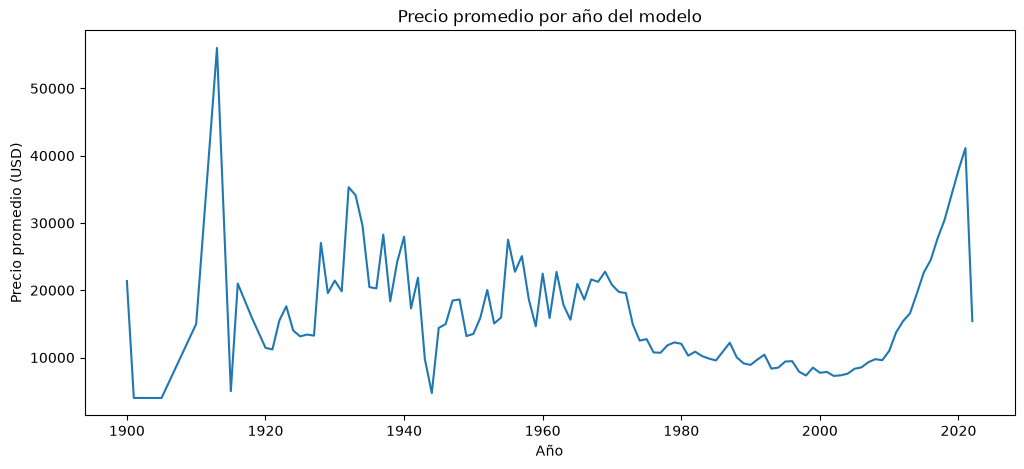

In [69]:
# Precio promedio por año del modelo
precio_modelo=df.groupby('year')['price'].mean().reset_index()

plt.figure(figsize=[12, 5])
plt.plot(precio_modelo['year'], precio_modelo['price'])
plt.title('Precio promedio por año del modelo')
plt.xlabel('Año')
plt.ylabel('Precio promedio (USD)')
plt.show()


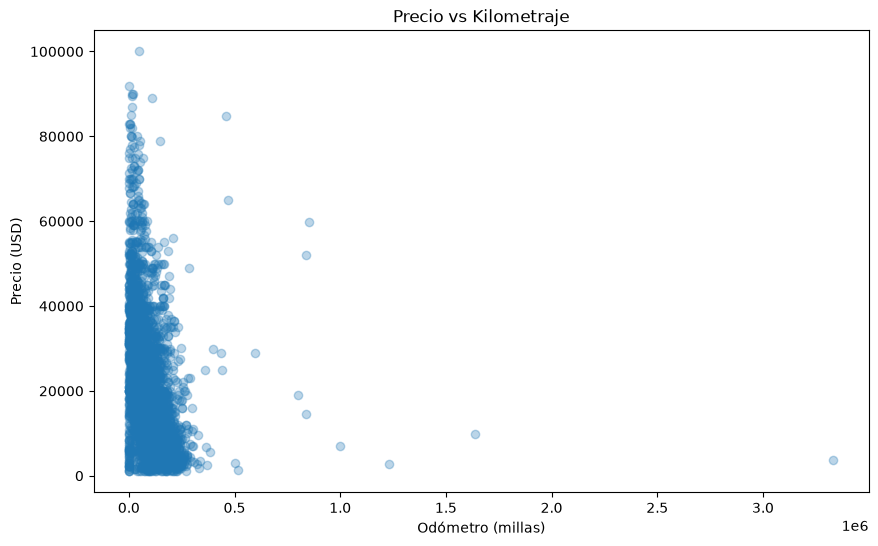

In [70]:
# Scatter odómetro vs precio (muestra aleatoria para no saturar)
muestra = df.sample(5000)
plt.figure(figsize=[10, 6])
plt.scatter(muestra['odometer'], muestra['price'], alpha=0.3)
plt.title('Precio vs Kilometraje')
plt.xlabel('Odómetro (millas)')
plt.ylabel('Precio (USD)')
plt.show()

Both charts confirm the calculated correlations. The average price by model year chart shows a clear upward trend for post-2010 vehicles. The odometer scatter plot shows higher dispersion — the negative trend exists (-0.20) but price is clearly influenced by multiple factors simultaneously, not just mileage.

Ambos gráficos confirman las correlaciones calculadas. La gráfica de precio promedio por año muestra una tendencia clara al alza en vehículos post-2010. El scatter del odómetro muestra mayor dispersión — la tendencia negativa existe (-0.20) pero el precio claramente depende de múltiples factores simultáneamente.

### Top 15 Manufacturers | Top 15 por fabricante
Let's analyze manufacturers from two perspectives: **average price** (which brands command higher prices?) and **total sales volume** (which brands dominate the market?).

Analizamos los fabricantes desde dos perspectivas: **precio promedio** (¿qué marcas tienen precios más altos?) y **volumen total de ventas** (¿qué marcas dominan el mercado?).

In [71]:
df_top_marcas = df.groupby('manufacturer')['price'].mean()
df_top_marcas = df_top_marcas.sort_values(ascending=False).head(15).reset_index()
print(df_top_marcas)

     manufacturer         price
0         ferrari  72810.526316
1    aston-martin  46560.555556
2           tesla  40866.514215
3         porsche  31044.846651
4             ram  30753.719990
5      alfa-romeo  29553.809802
6           rover  29375.100689
7          jaguar  27461.443787
8             gmc  25512.197787
9            audi  25168.878818
10  mercedes-benz  22364.952994
11       infiniti  21435.483680
12           ford  21418.962787
13          acura  21363.421739
14            bmw  21061.188440


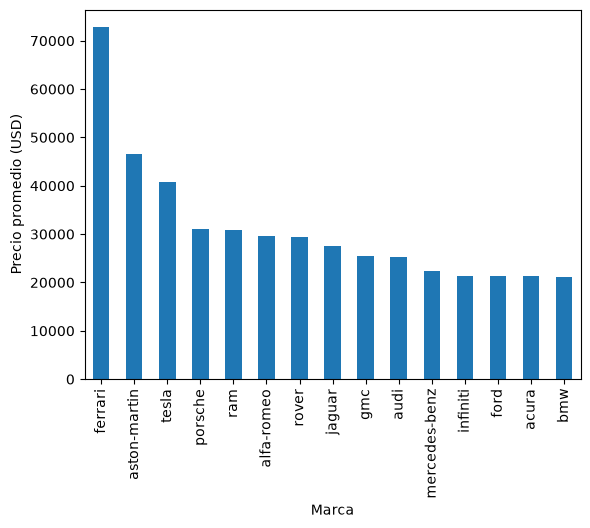

In [72]:
df_top_marcas.plot(
    kind = 'bar',
    xlabel = 'Marca',
    ylabel = 'Precio promedio (USD)',
    legend = False,
    x = 'manufacturer',
    y = 'price'
)

plt.show()

Premium brands dominate the average price ranking — Ferrari leads at $72,810/unit, followed by Aston-Martin ($46,560) and Tesla ($40,866). This makes sense as luxury vehicles command higher individual prices. 

Now let's compare against total sales volume to understand market dominance.

Las marcas premium dominan el ranking de precio promedio — Ferrari lidera con $72,810/unidad, seguida de Aston-Martin ($46,560) y Tesla ($40,866). Tiene sentido ya que los autos de lujo tienen precios unitarios elevados.

Comparemos ahora contra el volumen total de ventas para entender la dominancia de mercado.

In [73]:
df_top_marcas = df.groupby('manufacturer')['price'].sum()
df_top_marcas = df_top_marcas.sort_values(ascending=False).head(15).reset_index()
df_top_marcas = df_top_marcas.rename(columns = {'price': 'sales_per_brand'})
print(df_top_marcas)

     manufacturer  sales_per_brand
0            ford       1354899329
1       chevrolet       1000261968
2          toyota        538933170
3             ram        489076409
4             gmc        385030089
5            jeep        341821047
6             bmw        278744829
7           honda        228325692
8          nissan        223316200
9   mercedes-benz        222195808
10          dodge        194605323
11           audi        174672019
12          lexus        157216692
13       cadillac        132528951
14         subaru        123561165


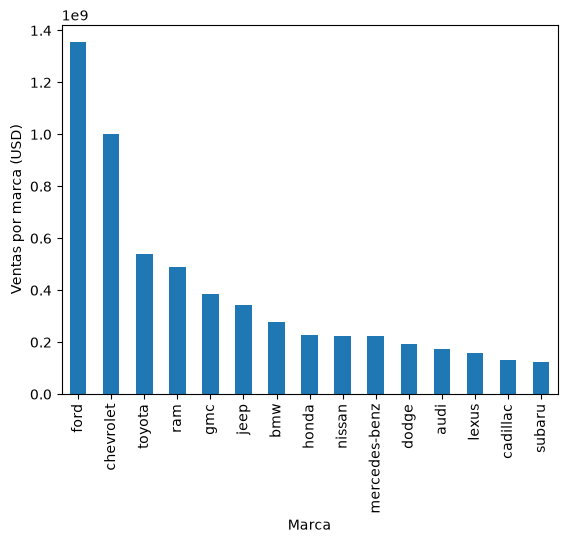

In [74]:
df_top_marcas.plot(
    kind = 'bar',
    xlabel = 'Marca',
    ylabel = 'Ventas por marca (USD)',
    legend = False,
    x = 'manufacturer',
    y = 'sales_per_brand'
)
plt.show()

The shift is dramatic. Ford leads total sales with ~$1.35B — nearly double Chevrolet's ~$1B. Premium brands like Ferrari and Aston-Martin, which topped the average price ranking, are virtually absent in volume terms. The mass market is clearly dominated by American brands (Ford, Chevrolet, RAM, GMC, Jeep), while premium brands achieve high unit prices but low volume.

El cambio es drástico. Ford lidera con ~$1.35B en ventas totales, casi el doble de Chevrolet (~$1B). Las marcas premium que lideraban por precio promedio desaparecen del top por volumen. El mercado masivo está dominado por marcas americanas mientras las premium tienen precios altos pero bajo volumen.

### Vehicle Type Analysis | Análisis por tipo de vehículo
Same two-perspective approach: average price and total sales volume by vehicle type.

Mismo enfoque de dos perspectivas: precio promedio y volumen total de ventas por tipo de vehículo.


#### Average price by vehicle type | Precio promedio por tipo de vehículo

In [75]:
df_tipos = df.groupby('type')['price'].mean()
df_tipos = df_tipos.sort_values(ascending=False).head(15).reset_index()
df_tipos = df_tipos.rename(columns = {'price': 'avg_price'})
print(df_tipos)

           type     avg_price
0        pickup  28831.088655
1         truck  27935.293041
2         other  27453.240436
3         coupe  22601.185510
4   convertible  20022.305967
5           van  18995.931958
6           SUV  18105.377521
7       offroad  16542.108247
8           bus  15489.058442
9     hatchback  15340.915917
10        sedan  14608.355023
11        wagon  14532.660341
12     mini-van   9980.007848


##### Visualizing average price | Visualización de precio promedio

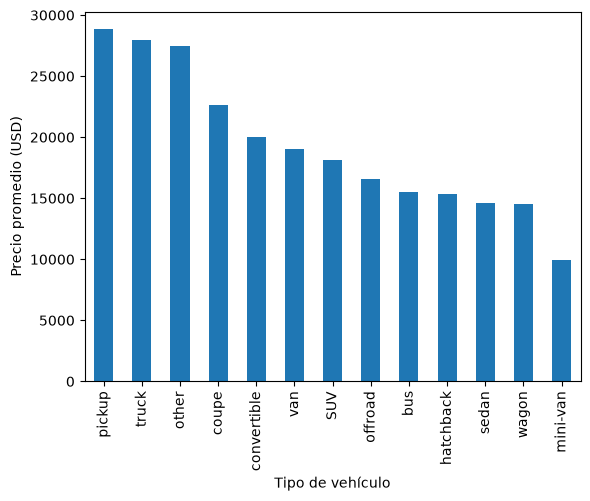

In [76]:
df_tipos.plot(
    kind = 'bar',
    x = 'type',
    y= 'avg_price',
    legend = False,
    xlabel = 'Tipo de vehículo',
    ylabel = 'Precio promedio (USD)'
)
plt.show()

#### Total sales volume by vehicle type | Volumen total de ventas por tipo de vehículo

           type  sales_per_type
0           SUV      1231002723
1        pickup      1183746838
2         sedan      1130818154
3         truck       822973733
4         other       536079426
5         coupe       396809014
6     hatchback       238643288
7           van       148244253
8   convertible       144621116
9         wagon       141664373
10     mini-van        44510835
11      offroad         9627507
12          bus         7155945


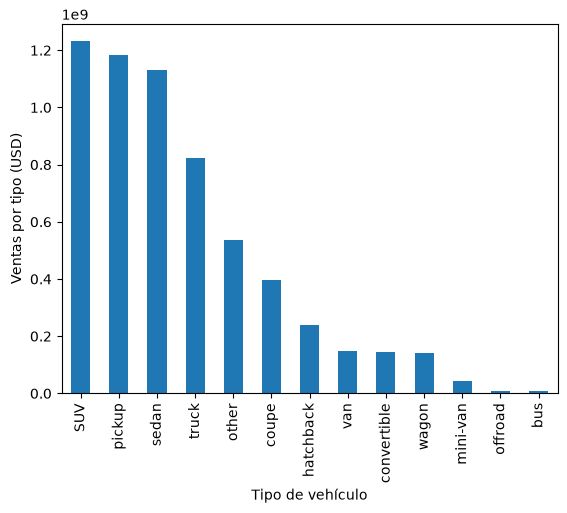

In [77]:
df_tipos = df.groupby('type')['price'].sum()
df_tipos = df_tipos.sort_values(ascending=False).head(15).reset_index()
df_tipos = df_tipos.rename(columns = {'price': 'sales_per_type'})
print(df_tipos)
df_tipos.plot(
    kind = 'bar',
    x = 'type',
    y= 'sales_per_type',
    legend = False,
    xlabel = 'Tipo de vehículo',
    ylabel = 'Ventas por tipo (USD)'
)
plt.show()

Pickup trucks lead in average price (#1 at $28,831) and are strong in volume (#2 at $1.18B). SUVs are the volume king (#1 at $1.23B) despite ranking #6 in average price — suggesting massive demand that compensates for the lower unit price. Mini-vans rank last in both metrics, confirming they are the least popular segment in this market.

Las pickup lideran en precio promedio (#1 con $28,831) y son fuertes en volumen (#2 con $1.18B). Los SUVs son el rey en volumen (#1 con $1.23B) a pesar de estar en el puesto #6 por precio promedio. Las mini-vans ocupan el último lugar en ambas métricas.

## General Conclusion | Conclusión general

The exploratory analysis of the U.S. used car market (Craigslist, 2021) reveals clear patterns about pricing behavior and buyer preferences.

**Pricing factors**: model year is the strongest price predictor (correlation: 0.37) — newer vehicles tend to cost significantly more, with a clear upward trend for post-2010 models. Mileage shows a moderate negative correlation (-0.20): higher odometer readings lead to lower prices, though price depends on multiple factors simultaneously.

**Manufacturers**: there is a clear divide between average price and sales volume. Ferrari and Aston-Martin lead in average price ($72,810 and $46,560 respectively) but are virtually absent in volume. The mass market is dominated by American brands — Ford leads total sales at ~$1.35B, nearly double Chevrolet's ~$1B, followed by Toyota, RAM and GMC.

**Vehicle types**: pickup trucks are the most consistent segment — leading in average price ($28,831) and ranking #2 in total volume ($1.18B). SUVs are the volume king (#1 at $1.23B) despite ranking #6 in average price, suggesting massive demand that compensates for the lower unit price. Mini-vans rank last in both metrics — the least popular segment in the market.

**Business implication**: for a platform, the most profitable segment by volume lies in SUVs and pickup trucks from American brands (Ford, Chevrolet, RAM, GMC) with post-2010 model years and moderate mileage — a combination that maximizes both sale price and market demand.

---

El análisis exploratorio del mercado de autos usados en Estados Unidos (Craigslist, 2021) revela patrones claros sobre el comportamiento de precios y preferencias de compra.

**Factores que afectan el precio**: el año del modelo es el factor con mayor correlación con el precio (0.37) — autos más recientes tienden a costar significativamente más, con una tendencia clara a partir de 2010. El kilometraje tiene una correlación negativa moderada (-0.20): a mayor odómetro, menor precio, aunque el precio depende de múltiples factores simultáneamente.

**Marcas**: existe una diferencia importante entre precio promedio y volumen de ventas. Ferrari y Aston-Martin lideran en precio promedio ($72,810 y $46,560 respectivamente), pero son prácticamente inexistentes en volumen. El mercado masivo está dominado por marcas americanas — Ford lidera en ventas totales con ~$1.35B, casi el doble de Chevrolet (~$1B), seguidas de Toyota, RAM y GMC.

**Tipo de vehículo**: las pickup son el segmento más consistente — lideran en precio promedio ($28,831) y ocupan el segundo lugar en volumen total ($1.18B). Los SUVs son el rey en volumen (#1 con $1.23B) a pesar de estar en el puesto #6 por precio promedio, lo que sugiere una demanda masiva que compensa el menor precio unitario. Las mini-vans ocupan el último lugar en ambas métricas — el segmento menos popular del mercado.

**Implicación de negocio**: para una plataforma, el segmento más rentable en términos de volumen está en SUVs y pickups de marcas americanas (Ford, Chevrolet, RAM, GMC) con modelos post-2010 y kilometraje moderado — combinación que maximiza tanto el precio de venta como la demanda del mercado.